**Fase de testes dos modelos: Treinado e Refinado**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importando os modelos**

In [ ]:
from tensorflow.keras.models import load_model

# Modelo apenas treinado
modelo_ = load_model("drive/MyDrive/trained_model/modelo.keras")
# Modelo refinado
modelo_ref = load_model("drive/MyDrive/finetuned/resnet50_finetuned_covid_pneumonia.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


**Baixando conjunto teste**

In [ ]:
# Baixando os arquivos de teste da covid-19
!wget "https://data.mendeley.com/public-files/datasets/2fxz4px6d8/files/014012df-dadd-4b84-8cb0-3219ea9feec5/file_downloaded"
!mkdir testes_covid
!unzip file_downloaded -d ./testes_covid
# Apagando os Non-COVID-19 e modificando o nome do diretório
!mv ./testes_covid/Dataset\ COVID-19\ Augmented ./testes_covid/data_test
!rm -rf ./testes_covid/data_test/Non-COVID-19
# Conjunto de testes de pneumonia
!unzip drive/MyDrive/pneumonia.zip -d ./
!mv PNEUMONIA/ pneumonia_testes

--2026-01-02 16:12:44--  https://data.mendeley.com/public-files/datasets/2fxz4px6d8/files/014012df-dadd-4b84-8cb0-3219ea9feec5/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/bc9f750d-b663-48a7-844e-4e8246751706 [following]
--2026-01-02 16:12:45--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/bc9f750d-b663-48a7-844e-4e8246751706
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.92.32.2, 3.5.70.127, 52.92.0.162, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.92.32.2|:443... con

# **Processamento dos Dados de Teste**

In [ ]:
import numpy as np

# Decodificador
def decode_preds(preds, threshold=0.5):
  preds = np.asarray(preds)
  # Validando o shape do preds
  if preds.ndim != 2 or preds.shape[1] != 1:
    raise ValueError(
        f"Formato inesperado de saída do modelo: {preds.shape}"
    )
  probs = preds[:, 0]
  labels = ["PNEUMONIA" if p >= threshold else "COVID" for p in probs]
  return probs, labels

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

def load_and_preprocess(img_path, target_size=(224, 224)):
    img = load_img(img_path, target_size=target_size)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

In [ ]:
import random
import os

caminho_covid = "./testes_covid/data_test/COVID-19"
caminho_pneumonia = "./pneumonia_testes/"
TARGET_SIZE = (224, 224)

# caminhos das imagens de covid
imagens_covid_path = [
    os.path.join(caminho_covid, fname)
    for fname in os.listdir(caminho_covid)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]
# caminhos das imagens de pneumonia
imagens_pneumonia_path = [
    os.path.join(caminho_pneumonia, fname)
    for fname in os.listdir(caminho_pneumonia)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]

# Caminhos das duas doenças
n = 900
image_caminhos = (
    random.sample(imagens_covid_path, n) +
    random.sample(imagens_pneumonia_path, n)
)

batches = [load_and_preprocess(p) for p in image_caminhos]
X_test = np.vstack(batches)

# Shape do X_test Atual
print("X_test shape:", X_test.shape)
print(len(image_caminhos))

assert len(X_test) == len(image_caminhos)

X_test shape: (1800, 224, 224, 3)
1800


# Testando os Modelos

In [ ]:
# modelo apenas treinado
predict_ = modelo_.predict(X_test)
probs, labels = decode_preds(predict_)

57/57 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step


In [ ]:
# modelo refinado
predict_ref = modelo_ref.predict(X_test)
probs, labels = decode_preds(predict_ref)

57/57 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step


In [ ]:
y_test = np.array([
    0 if "COVID" in p.upper() else 1
    for p in image_caminhos
])
probs = predict_.ravel()              # (N,1) → (N,)
y_pred = (probs >= 0.5).astype(int)    # threshold


In [ ]:
y_test_ref = np.array([
    0 if "COVID" in p.upper() else 1
    for p in image_caminhos
])
probs = predict_ref.ravel()
y_pred_ref = (probs >= 0.5).astype(int)


In [ ]:
# Avaliação de acertos do modelo apenas treinado
acertos = (y_pred == y_test)
print(f"Acertos: {acertos.sum()} / {len(y_test)}")
print(f"Acurácia: {acertos.mean():.4f}")

Acertos: 1644 / 1800
Acurácia: 0.9133


In [ ]:
# Avaliação de acertos do modelo refinado
acertos_ref = (y_pred_ref == y_test_ref)
print(f"Acertos: {acertos_ref.sum()} / {len(y_test)}")
print(f"Acurácia: {acertos_ref.mean():.4f}")

Acertos: 1658 / 1800
Acurácia: 0.9211


# Vizualizando as métricas

In [ ]:
# Modelo apenas treinado
from sklearn.metrics import confusion_matrix, classification_report
cm_ = confusion_matrix(y_test, y_pred)
print(cm_)
print(classification_report(
    y_test, y_pred,
    target_names=["PNEUMONIA", "COVID"]
))


[[744 156]
 [  0 900]]
              precision    recall  f1-score   support

   PNEUMONIA       1.00      0.83      0.91       900
       COVID       0.85      1.00      0.92       900

    accuracy                           0.91      1800
   macro avg       0.93      0.91      0.91      1800
weighted avg       0.93      0.91      0.91      1800



In [ ]:
# Modelo refinado
cm_ref = confusion_matrix(y_test_ref, y_pred_ref)
print(cm_ref)
print(classification_report(
    y_test_ref, y_pred_ref,
    target_names=["PNEUMONIA", "COVID"]
))


[[758 142]
 [  0 900]]
              precision    recall  f1-score   support

   PNEUMONIA       1.00      0.84      0.91       900
       COVID       0.86      1.00      0.93       900

    accuracy                           0.92      1800
   macro avg       0.93      0.92      0.92      1800
weighted avg       0.93      0.92      0.92      1800



**Vizualizando matriz de Confusão**

Text(0.5, 1.0, 'Modelo Refinado')

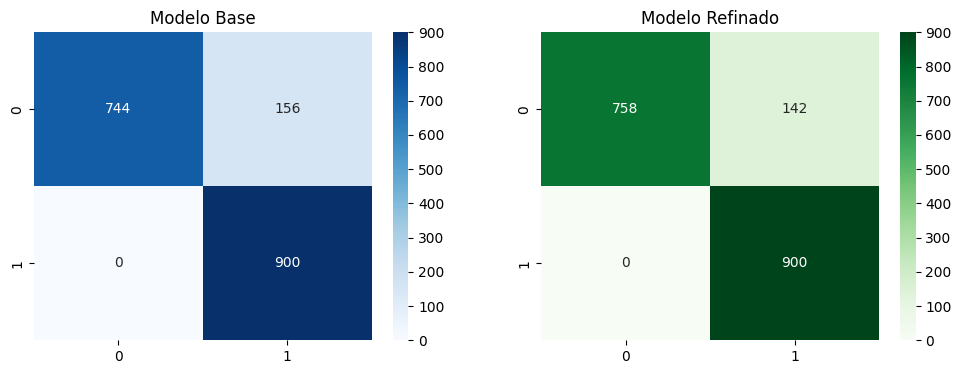

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_, annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Modelo Base")

sns.heatmap(cm_ref, annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Modelo Refinado")
